# 1 - Setup

In [ ]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing.load_data import load_test, load_train
from src.preprocessing.rul import compute_train_rul, compute_test_rul

DATA_DIR = ROOT / "data"
RAW_DIR  = DATA_DIR / "loaded"


In [3]:
print("Loading training files...")
train = pd.read_csv(RAW_DIR / "train_rul.csv")
train.head(3)

Loading training files...


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.0,10.62,6.3670,125
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.0,24.37,14.6552,125
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.0,10.48,6.4213,125


In [4]:
print("Loading test files...")
test = pd.read_csv(RAW_DIR / "test_rul.csv")
test.head(3)

Loading test files...


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,20.0072,0.700,100.0,491.19,606.67,1481.04,1227.81,9.35,...,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007,125
1,1,2,24.9984,0.620,60.0,462.54,536.22,1256.17,1031.48,7.05,...,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748,125
2,1,3,42.0000,0.842,100.0,445.00,549.23,1340.13,1105.88,3.91,...,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365,125


## 2 - Engine lifetime distribution

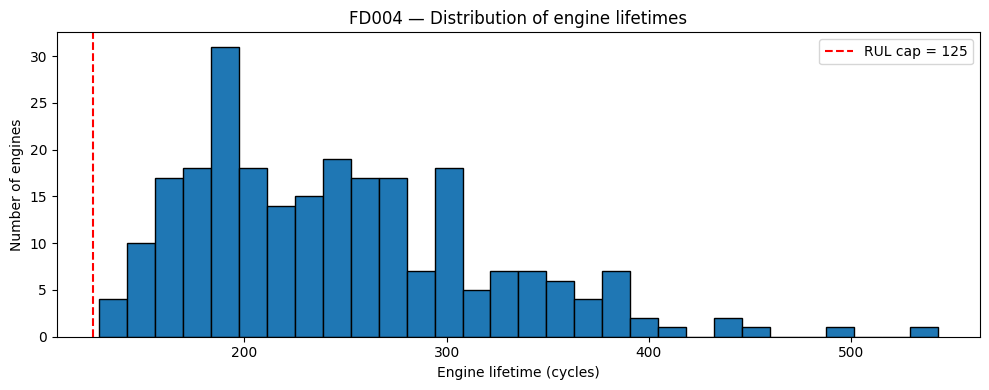

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: cycle, dtype: float64

Minimum lifetime (128) > RUL cap (125): True


In [5]:
# Justifies RUL cap of 125
lifetimes = train.groupby("engine_id")["cycle"].max().sort_values()

plt.figure(figsize=(10, 4))
plt.hist(lifetimes, bins=30, edgecolor="black")
plt.axvline(125, color="red", linestyle="--", label="RUL cap = 125")
plt.xlabel("Engine lifetime (cycles)")
plt.ylabel("Number of engines")
plt.title("FD004 — Distribution of engine lifetimes")
plt.legend()
plt.tight_layout()
plt.show()

print(lifetimes.describe())
print(f"\nMinimum lifetime ({lifetimes.min()}) > RUL cap (125): {lifetimes.min() > 125}")

 ## 3 - Operating conditions

Unique op1 values: 536
Unique op2 values: 105
Unique op3 values: 2


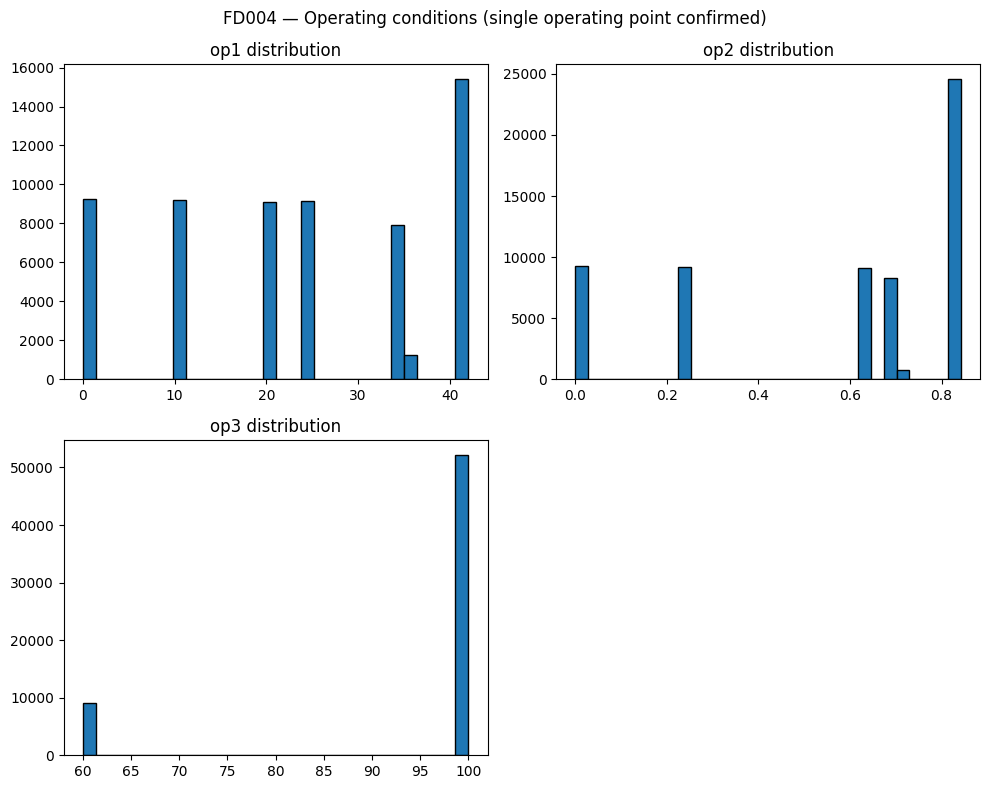

In [6]:
# Justifies no clustering needed for FD001
print("Unique op1 values:", train["op1"].nunique())
print("Unique op2 values:", train["op2"].nunique())
print("Unique op3 values:", train["op3"].nunique())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

cols = ["op1", "op2", "op3"]

for i, col in enumerate(cols):
    r, c = i // 2, i % 2
    axes[r, c].hist(train[col], bins=30, edgecolor="black")
    axes[r, c].set_title(f"{col} distribution")

# Hide empty subplot
axes[1, 1].axis("off")

plt.suptitle("FD004 — Operating conditions (single operating point confirmed)")
plt.tight_layout()
plt.show()

## 4 — Pick 3 representative engines (defined once, used everywhere below)

In [7]:
# Define short/average/long-lived engines here — used in all trajectory plots
short_engine = lifetimes.index[0]
avg_engine   = lifetimes.index[len(lifetimes)//2]
long_engine  = lifetimes.index[-1]

print(f"Short:   Engine {short_engine} ({lifetimes[short_engine]} cycles)")
print(f"Average: Engine {avg_engine}  ({lifetimes[avg_engine]} cycles)")
print(f"Long:    Engine {long_engine}  ({lifetimes[long_engine]} cycles)")

Short:   Engine 214 (128 cycles)
Average: Engine 147  (234 cycles)
Long:    Engine 118  (543 cycles)


## 5 - Sensor variance

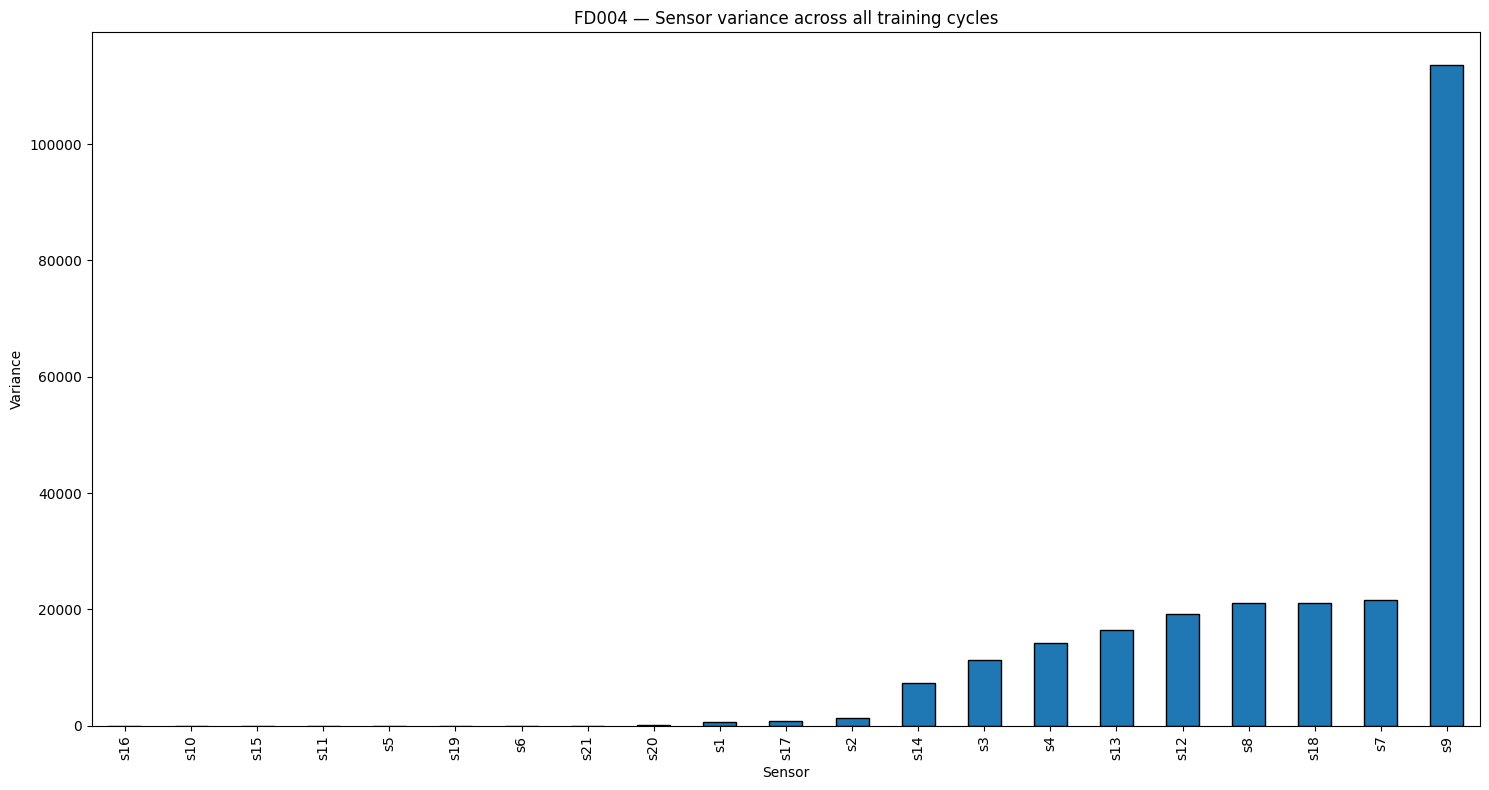

s16         0.000022
s10         0.016302
s15         0.563061
s11        10.520237
s5         13.125202
s19        28.830710
s6         29.637316
s21        35.553759
s20        98.731968
s1        698.906067
s17       773.300629
s2       1394.473263
s14      7339.442015
s3      11271.558809
s4      14239.073899
s13     16434.691116
s12     19176.463675
s8      21126.111710
s18     21162.245693
s7      21573.795950
s9     113520.171620
dtype: float64

Zero variance sensors (drop immediately): []
Borderline sensors (need trajectory + correlation check): ['s16', 's10']


In [8]:
# Step 1 of sensor selection: measure variance
# This shows which sensors are candidates for dropping — not the final decision
sensor_cols = [f"s{i}" for i in range(1, 22)]
variances = train[sensor_cols].var().sort_values()

plt.figure(figsize=(15, 8))
variances.plot(kind="bar", edgecolor="black")
plt.xlabel("Sensor")
plt.ylabel("Variance")
plt.title("FD004 — Sensor variance across all training cycles")
plt.tight_layout()
plt.show()

print(variances)

# Sensors with literally zero variance — mathematically constant, drop immediately
zero_var = variances[variances < 1e-10].index.tolist()
print(f"\nZero variance sensors (drop immediately): {zero_var}")

# Sensors that need further investigation
needs_check = variances[(variances >= 1e-10) & (variances < 0.1)].index.tolist()
print(f"Borderline sensors (need trajectory + correlation check): {needs_check}")

## 6 — Correlation with RUL

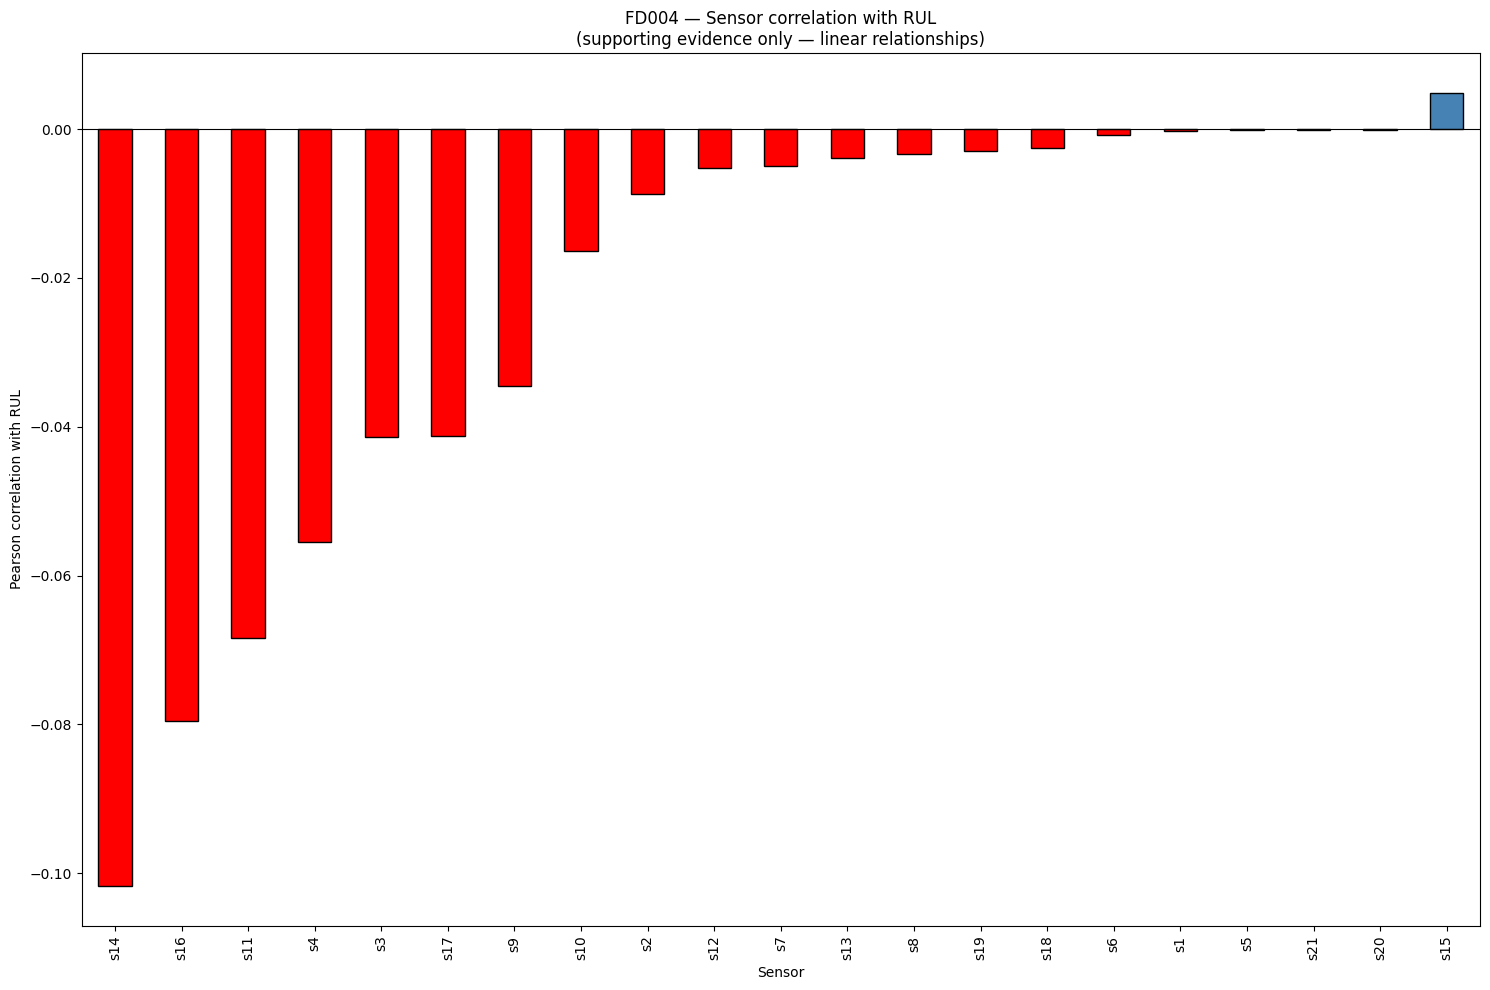

s14   -0.101742
s16   -0.079599
s11   -0.068388
s4    -0.055503
s3    -0.041335
s17   -0.041220
s9    -0.034534
s10   -0.016340
s2    -0.008745
s12   -0.005180
s7    -0.004954
s13   -0.003912
s8    -0.003379
s19   -0.002965
s18   -0.002582
s6    -0.000776
s1    -0.000304
s5    -0.000170
s21   -0.000133
s20   -0.000131
s15    0.004875
dtype: float64


In [9]:
correlations = train[sensor_cols].corrwith(train["RUL"]).sort_values()

plt.figure(figsize=(15, 10))
correlations.plot(
    kind="bar",
    edgecolor="black",
    color=["red" if x < 0 else "steelblue" for x in correlations]
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Sensor")
plt.ylabel("Pearson correlation with RUL")
plt.title("FD004 — Sensor correlation with RUL\n(supporting evidence only — linear relationships)")
plt.tight_layout()
plt.show()

print(correlations)

## 7 — Trajectory plots for ALL non-zero sensors

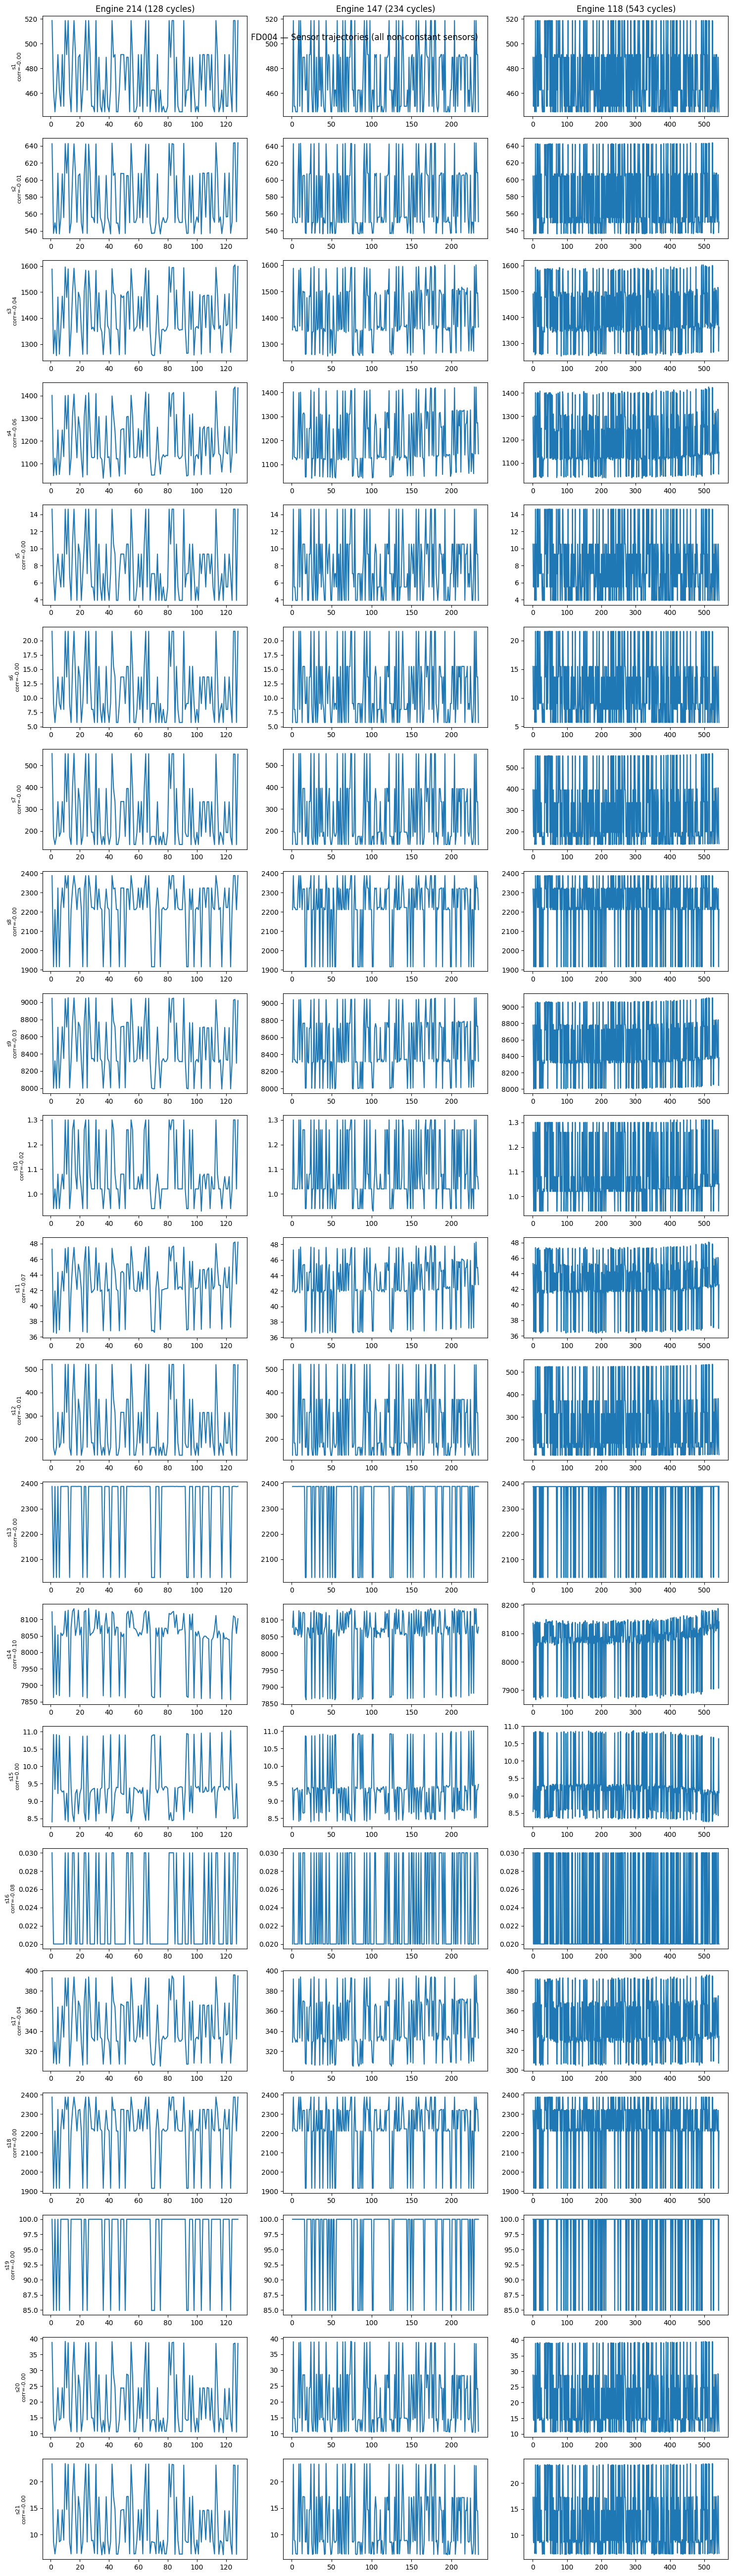

In [10]:
# Step 3: visual trajectory check — the most important criterion
# A sensor with any visible monotonic trend is kept regardless of variance
# Drop ONLY if: zero/near-zero variance AND weak correlation AND visually flat

check_sensors = [s for s in sensor_cols if s not in zero_var]

fig, axes = plt.subplots(len(check_sensors), 3, figsize=(15, len(check_sensors)*2.5))

for col_idx, engine_id in enumerate([short_engine, avg_engine, long_engine]):
    engine_data = train[train["engine_id"] == engine_id].sort_values("cycle")
    for row_idx, sensor in enumerate(check_sensors):
        ax = axes[row_idx, col_idx]
        ax.plot(engine_data["cycle"], engine_data[sensor])
        if row_idx == 0:
            ax.set_title(f"Engine {engine_id} ({len(engine_data)} cycles)")
        if col_idx == 0:
            corr = correlations[sensor]
            ax.set_ylabel(f"{sensor}\ncorr={corr:.2f}", fontsize=8)

plt.suptitle("FD004 — Sensor trajectories (all non-constant sensors)")
plt.tight_layout()
plt.show()

## 8 — Final sensor selection decision

In [11]:
# FINAL DECISION — based on all three criteria jointly:
# 1. Variance  2. Pearson correlation  3. Visual trajectory
#
# DROPPED:
# s1, s5, s10, s16, s18, s19 — zero variance, mathematically constant
# s6 — near-zero variance (1.9e-6), weak correlation (-0.108), flat trajectory
#
# KEPT (14 sensors):
# All show clear monotonic trends in trajectory plots
# Pearson correlation used as supporting evidence only, not sole criterion

sensors_to_drop = ["s1", "s5", "s6", "s10", "s16", "s18", "s19"]
kept_sensors    = [s for s in sensor_cols if s not in sensors_to_drop]

print(f"Dropped ({len(sensors_to_drop)}): {sensors_to_drop}")
print(f"Kept    ({len(kept_sensors)}): {kept_sensors}")

# Summary table
print("\nSensor selection summary:")
print(f"{'Sensor':<8} {'Variance':<15} {'Corr w/ RUL':<15} {'Decision'}")
print("-" * 50)
for s in sensor_cols:
    var = variances[s]
    corr = correlations[s] if s in correlations else float('nan')
    decision = "DROP" if s in sensors_to_drop else "KEEP"
    print(f"{s:<8} {var:<15.6f} {corr:<15.3f} {decision}")

Dropped (7): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Kept    (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

Sensor selection summary:
Sensor   Variance        Corr w/ RUL     Decision
--------------------------------------------------
s1       698.906067      -0.000          DROP
s2       1394.473263     -0.009          KEEP
s3       11271.558809    -0.041          KEEP
s4       14239.073899    -0.056          KEEP
s5       13.125202       -0.000          DROP
s6       29.637316       -0.001          DROP
s7       21573.795950    -0.005          KEEP
s8       21126.111710    -0.003          KEEP
s9       113520.171620   -0.035          KEEP
s10      0.016302        -0.016          DROP
s11      10.520237       -0.068          KEEP
s12      19176.463675    -0.005          KEEP
s13      16434.691116    -0.004          KEEP
s14      7339.442015     -0.102          KEEP
s15      0.563061        0.005           KEEP
s16      0.0000

## 9 — Average trajectory (nonlinearity evidence)

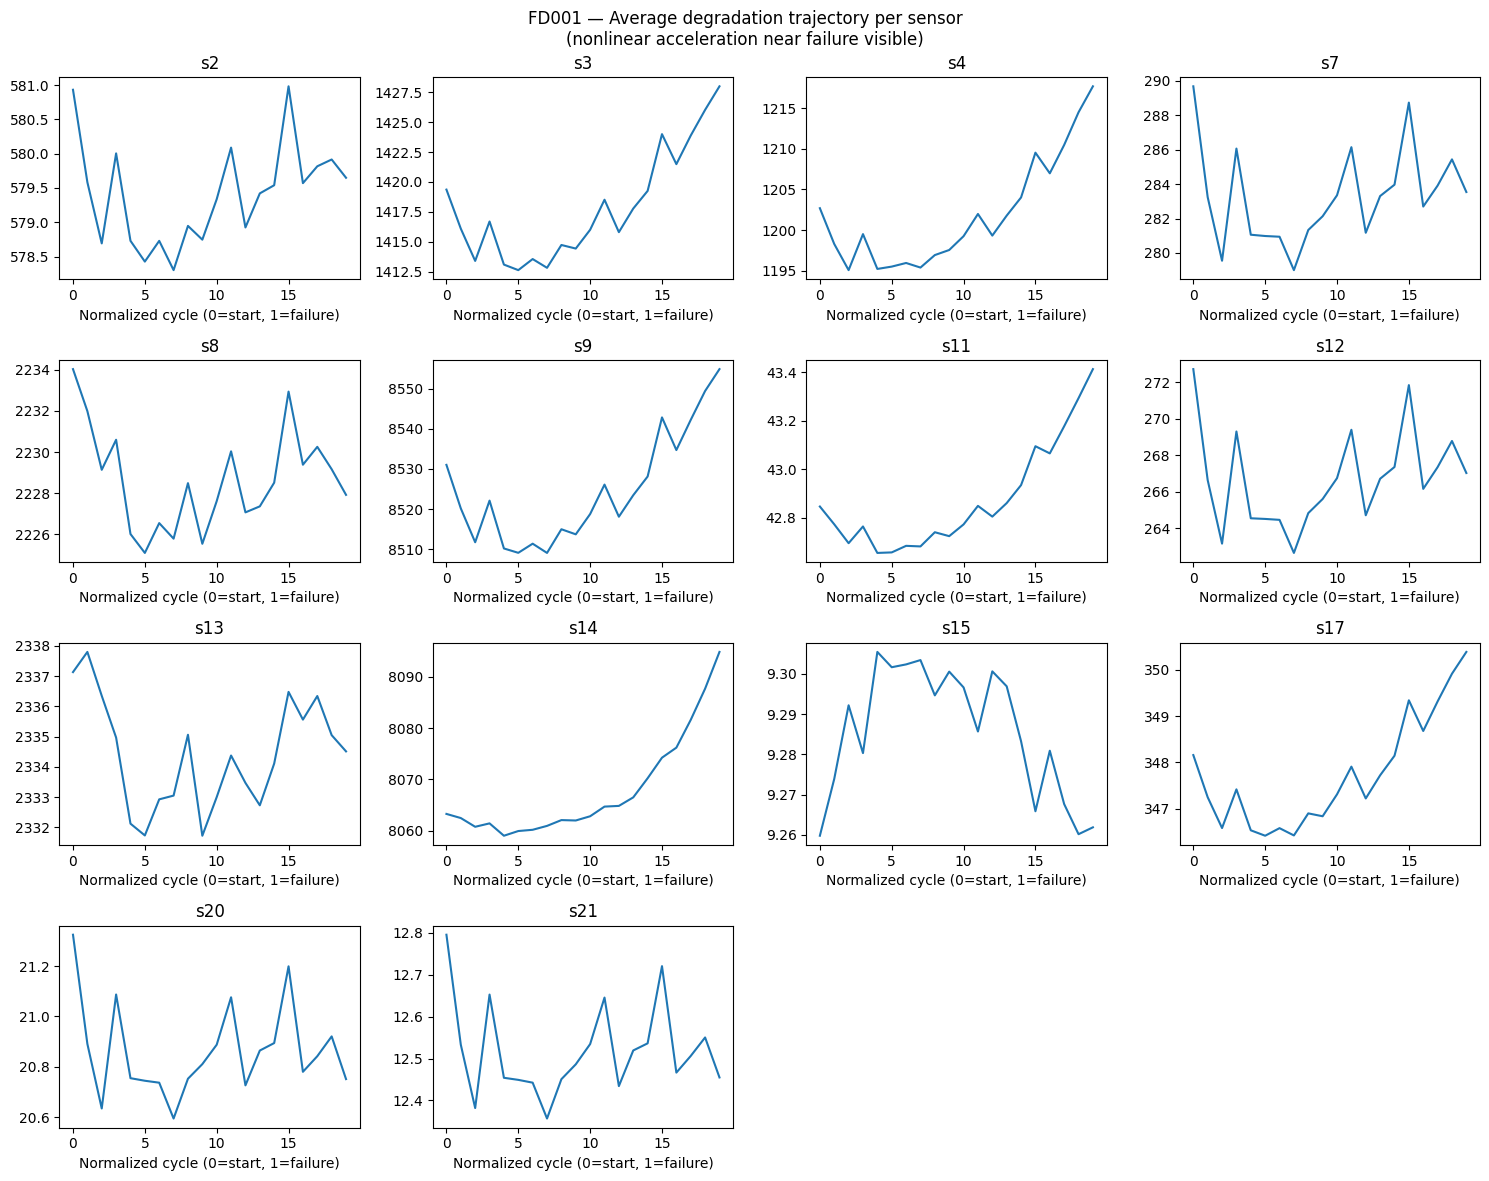

In [12]:
# Shows that degradation is nonlinear — justifies DL over ARIMA near end-of-life
train["cycle_norm"] = train.groupby("engine_id")["cycle"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
train["cycle_bin"] = pd.cut(train["cycle_norm"], bins=20, labels=False)
avg_trajectory = train.groupby("cycle_bin")[kept_sensors].mean()

n = len(kept_sensors)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))
axes = axes.flatten()

for i, sensor in enumerate(kept_sensors):
    axes[i].plot(avg_trajectory.index, avg_trajectory[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel("Normalized cycle (0=start, 1=failure)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("FD001 — Average degradation trajectory per sensor\n(nonlinear acceleration near failure visible)")
plt.tight_layout()
plt.show()

# Drop EDA-only columns so train is not polluted for downstream use
train = train.drop(columns=["cycle_norm", "cycle_bin"])